In [22]:
from functions import get_experiment_data
import pandas as pd
import numpy as np
CONFOUNDED_STUDIES = [
    "Monaco.2016",
    "Pinto-Cardoso.2017",
    "Villanueva-Millan.2017",
    "Yu.2014",
]

EXPERIMENT_DESIGNS = {
    "df1": {
        "name": "full_raw_norm",
        "aggregation": None,
        "subset_studies": None,
    
        "cleanset_filtering" : False,
        "normalize" : True,
        "otu_zeroprev" : 0.01,
        "sample_zeroprev": None,
           
        "description": "Full raw HIVRC, normalized, standalone LatentGEE",
    },
    
    "df2": {
        "name": "minproc_otu_count",
        "aggregation": None,
        "subset_studies": None,
        "cleanset_filtering": False,
        "normalize": False,
        "otu_zeroprev": None,
        "sample_zeroprev": None,
        "description": "Minimally processed HIVRC at the OTU level, raw count",
    },
    "df3": {
        "name": "prep_genus_norm",
        "aggregation": "genus",
        "subset_studies": None,
        
        "cleanset_filtering" : True,
        "normalize" : True,
        "otu_zeroprev" : None,
        "sample_zeroprev": None,
    
        "description": "Preprocessed HIVRC, genus-level, normalized",
    },
    "df4": {
        "name": "prep_genus_count",
        "aggregation": "genus",
        "subset_studies": None,
                
        "cleanset_filtering" : True,
        "normalize" : False,
        "otu_zeroprev" : None,
        "sample_zeroprev": None,
        
        "description": "Preprocessed HIVRC, genus-level, raw count",
    },
    "df5": {
        "name": "subset_genus_norm",
        "aggregation": "genus",
        
        "cleanset_filtering" : True,
        "normalize" : True,
        "otu_zeroprev" : None,
        "sample_zeroprev": None,
        
        "subset_studies": CONFOUNDED_STUDIES,
        "description": "Confounded subset HIVRC, genus-level, normalized",
    },
    "df6": {
        "name": "subset_genus_count",
        "aggregation": "genus",
        
        "cleanset_filtering" : True,
        "normalize" : False,
        "otu_zeroprev" : None,
        "sample_zeroprev": None,
        
        "subset_studies": CONFOUNDED_STUDIES,
        "description": "Confounded subset HIVRC, genus-level, raw count",
    },
    "df7": {
        "name": "prep_otu_norm",
        "normalize": True,
        "aggregation": None,
        
        "cleanset_filtering" : True,
        "otu_zeroprev" : None,
        "sample_zeroprev": None,
        
        "subset_studies": None,
        "description": "Preprocessed HIVRC, OTU-level, normalized",
    },
    "df8": {
        "name": "prep_otu_count",
        "normalize": False,
        "aggregation": None,
        
        "cleanset_filtering" : True,
        "otu_zeroprev" : None,
        "sample_zeroprev": None,
        
        "subset_studies": None,
        "description": "Preprocessed HIVRC, OTU-level, raw count",
    },
    "df9": {
        "name": "subset_otu_norm",
        
        "normalize": True,
        "aggregation": None,
        
        "cleanset_filtering" : True,
        "otu_zeroprev" : None,
        "sample_zeroprev": None,
        
        "subset_studies": CONFOUNDED_STUDIES,
        "description": "Confounded subset HIVRC, OTU-level, normalized",
    },
    "df10": {
        "name": "subset_otu_count",
        
        "normalize": False,
        "aggregation": None,
        
        "cleanset_filtering" : True,
        "otu_zeroprev" : None,
        "sample_zeroprev": None,
        
        "subset_studies": CONFOUNDED_STUDIES,
        "description": "Confounded subset HIVRC, OTU-level, raw count",
    },
}

X_df1, meta_df1, batch_df1, _ = get_experiment_data(
    design_id="df1",
    file_path="/DATA/WGS_study/YSL/projects/Data",
    verbose=True,
)
X_df3, meta_df3, batch_df3, _ = get_experiment_data(
    design_id="df3",
    file_path="/DATA/WGS_study/YSL/projects/Data",
    verbose=True,
)
X_df4, meta_df4, batch_df4, _ = get_experiment_data(
    design_id="df4",
    file_path="/DATA/WGS_study/YSL/projects/Data",
    verbose=True,
)

X_corrected_df1 = pd.read_csv(
    "/DATA/WGS_study/YSL/projects/latentgee/examples/results/df1/phase2/df1_X_corrected_trial2064_cutoff0.01_2026-05-08.csv",
    index_col=0
)
X_corrected_df3 = pd.read_csv(
    "/DATA/WGS_study/YSL/projects/latentgee/examples/results/df3/phase2/df3_X_corrected_trial2515_cutoff0.005_2026-04-24.csv",
    index_col=0
)
X_corrected_df4 = pd.read_csv(
    "/DATA/WGS_study/YSL/projects/latentgee/examples/results/df4/phase2/df4_X_corrected_trial4746_cutoff0.1_2026-04-27.csv",
    index_col=0
)

X_filtered_df1 = pd.read_csv(
    "/DATA/WGS_study/YSL/projects/latentgee/examples/data/X_df1_filtered_cutoff0.01.csv",
    index_col=0
)
X_filtered_df3 = pd.read_csv(
    "/DATA/WGS_study/YSL/projects/latentgee/examples/data/X_df3_filtered_cutoff0.005.csv",
    index_col=0
)
X_filtered_df4 = pd.read_csv(
    "/DATA/WGS_study/YSL/projects/latentgee/examples/data/X_df4_filtered_cutoff0.1.csv",
    index_col=0
)


def clean_corrected(X, clip_percentile=99.9):
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0).clip(lower=0)
    
    # percentile 기반 upper clipping
    upper = np.percentile(X.values[X.values > 0], clip_percentile)
    print(f"upper clip threshold ({clip_percentile}th): {upper:.6f}")
    X = X.clip(upper=upper)
    
    # re-normalization
    row_sums = X.sum(axis=1)
    row_sums[row_sums == 0] = 1
    X = X.div(row_sums, axis=0)
    return X

X_corrected_df1_clean = clean_corrected(X_corrected_df1, clip_percentile=99.9)
X_corrected_df3_clean = clean_corrected(X_corrected_df3, clip_percentile=99.9)
X_corrected_df4_clean = clean_corrected(X_corrected_df4, clip_percentile=99.9)

# 확인
for name, X in [("df1", X_corrected_df1_clean),
                ("df3", X_corrected_df3_clean),
                ("df4", X_corrected_df4_clean)]:
    print(f"{name} — max: {X.values.max():.6f}, row_sum mean: {X.sum(axis=1).mean():.4f}")


print(f"X_df1 shape: {X_df1.shape}")
print(f"X_filtered_df1 shape: {X_filtered_df1.shape}")
print(f"X_corrected_df1_clean shape: {X_corrected_df1_clean.shape}")
print()
print(f"X_df3 shape: {X_df3.shape}")
print(f"X_filtered_df3 shape: {X_filtered_df3.shape}")
print(f"X_corrected_df3_clean shape: {X_corrected_df3_clean.shape}")
print()
print(f"X_df4 shape: {X_df4.shape}")
print(f"X_filtered_df4 shape: {X_filtered_df4.shape}")
print(f"X_corrected_df4_clean shape: {X_corrected_df4_clean.shape}")

Design ID               : df1
Design name             : full_raw_norm
Description             : Full raw HIVRC, normalized, standalone LatentGEE
Aggregation             : None
Normalize               : True
Cleanset Filtering      : False
Subset studies          : None
OTU zero-prev           : 0.01
Sample zero-prev        : None
----------------------------------------------------------------------
feature_table           : (1032, 2485)
meta_data               : (1032, 11)
n_batches               : 17
Design ID               : df3
Design name             : prep_genus_norm
Description             : Preprocessed HIVRC, genus-level, normalized
Aggregation             : genus
Normalize               : True
Cleanset Filtering      : True
Subset studies          : None
OTU zero-prev           : None
Sample zero-prev        : None
----------------------------------------------------------------------
feature_table           : (936, 668)
meta_data               : (936, 11)
n_batches          

In [23]:
from functions import evaluate_batch_correction
# df1 — relative abundance → renormalize=True
df1_result = evaluate_batch_correction(
    X_before     = X_df1,
    X_after      = X_corrected_df1_clean,
    batch_labels = batch_df1,
    bio_labels   = meta_df1['hivstatus'],
    renormalize  = True,
    label        = "df1 — LatentGEE standalone"
)

# df3 — relative abundance → renormalize=True
df3_result = evaluate_batch_correction(
    X_before     = X_df3,
    X_after      = X_corrected_df3_clean,
    batch_labels = batch_df3,
    bio_labels   = meta_df3['hivstatus'],
    renormalize  = True,
    label        = "df3 — LatentGEE"
)

# df4 — raw count → renormalize=False
df4_result = evaluate_batch_correction(
    X_before     = X_df4,
    X_after      = X_corrected_df4_clean,
    batch_labels = batch_df4,
    bio_labels   = meta_df4['hivstatus'],
    renormalize  = False,
    label        = "df4 — LatentGEE"
)


  df1 — LatentGEE standalone
                        Before   After  Change
Metric                                        
PERMANOVA R² (batch) ↓  0.2092  0.0179 -0.1913
PERMANOVA R² (bio) ↑    0.0026  0.0009 -0.0017
kBET acceptance rate ↑  0.0901  0.3634  0.2733
ASW (batch) → 0        -0.0316 -0.1529 -0.1213
ASW (bio) ↑            -0.0227  0.0053  0.0280


  df3 — LatentGEE
                        Before   After  Change
Metric                                        
PERMANOVA R² (batch) ↓  0.1835  0.0556 -0.1279
PERMANOVA R² (bio) ↑    0.0041  0.0015 -0.0027
kBET acceptance rate ↑  0.2051  0.7917  0.5865
ASW (batch) → 0        -0.1002 -0.0872  0.0130
ASW (bio) ↑            -0.0245 -0.0109  0.0136


  df4 — LatentGEE
                        Before   After  Change
Metric                                        
PERMANOVA R² (batch) ↓  0.2649  0.0145 -0.2504
PERMANOVA R² (bio) ↑    0.0039  0.0011 -0.0028
kBET acceptance rate ↑  0.0085  0.9306  0.9220
ASW (batch) → 0        -0.1330 -0.032

In [24]:
# 데이터 구조 확인
print("=== df1 ===")
print(f"X_df1: {X_df1.shape}")
print(f"X_corrected_df1: {X_corrected_df1_clean.shape}")
print(f"batch_df1 unique: {len(np.unique(batch_df1))}개 → {np.unique(batch_df1)[:5]}")

print("\n=== df3 ===")
print(f"X_df3: {X_df3.shape}")
print(f"X_corrected_df3: {X_corrected_df3_clean.shape}")
print(f"batch_df3 unique: {len(np.unique(batch_df3))}개 → {np.unique(batch_df3)[:5]}")

print("\n=== df4 ===")
print(f"X_df4: {X_df4.shape}")
print(f"X_corrected_df4: {X_corrected_df4_clean.shape}")
print(f"batch_df4 unique: {len(np.unique(batch_df4))}개 → {np.unique(batch_df4)[:5]}")

=== df1 ===
X_df1: (1032, 2485)
X_corrected_df1: (1032, 2485)
batch_df1 unique: 17개 → ['Dillon' 'Dinh' 'Dubourg' 'Lozupone 2013' 'Monaco']

=== df3 ===
X_df3: (936, 668)
X_corrected_df3: (936, 353)
batch_df3 unique: 14개 → ['Dillon' 'Dinh' 'Dubourg' 'Lozupone 2013' 'Monaco']

=== df4 ===
X_df4: (936, 668)
X_corrected_df4: (936, 135)
batch_df4 unique: 14개 → ['Dillon' 'Dinh' 'Dubourg' 'Lozupone 2013' 'Monaco']


In [16]:
print(f"X_filtered_df1 == X_corrected_df1: {(X_filtered_df1.index == X_corrected_df1_clean.index).all()}")
print(f"X_filtered_df3 == X_corrected_df3: {(X_filtered_df3.index == X_corrected_df3_clean.index).all()}")
print(f"X_filtered_df4 == X_corrected_df4: {(X_filtered_df4.index == X_corrected_df4_clean.index).all()}")

X_filtered_df1 == X_corrected_df1: True
X_filtered_df3 == X_corrected_df3: True
X_filtered_df4 == X_corrected_df4: True


/tmp/ipykernel_1115015/4287125654.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(all_studies))


저장됨: /DATA/WGS_study/YSL/projects/latentgee/examples/results/figures/pcoa_braycurtis.png


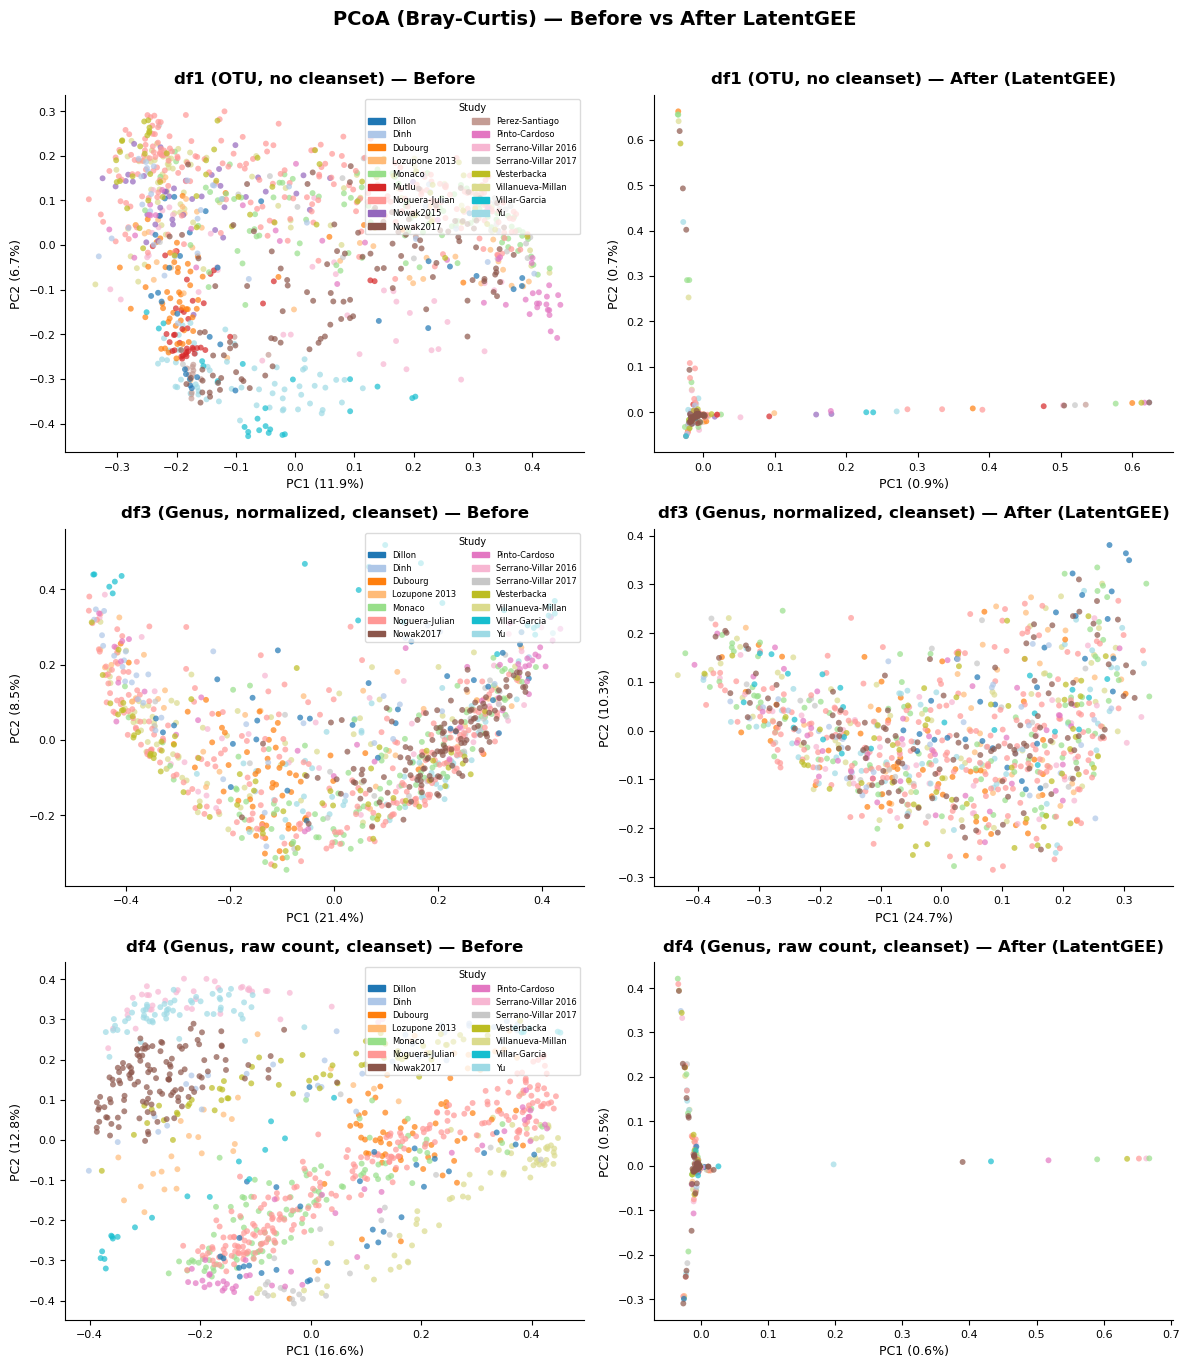

저장됨: /DATA/WGS_study/YSL/projects/latentgee/examples/results/figures/pcoa_euclidean.png


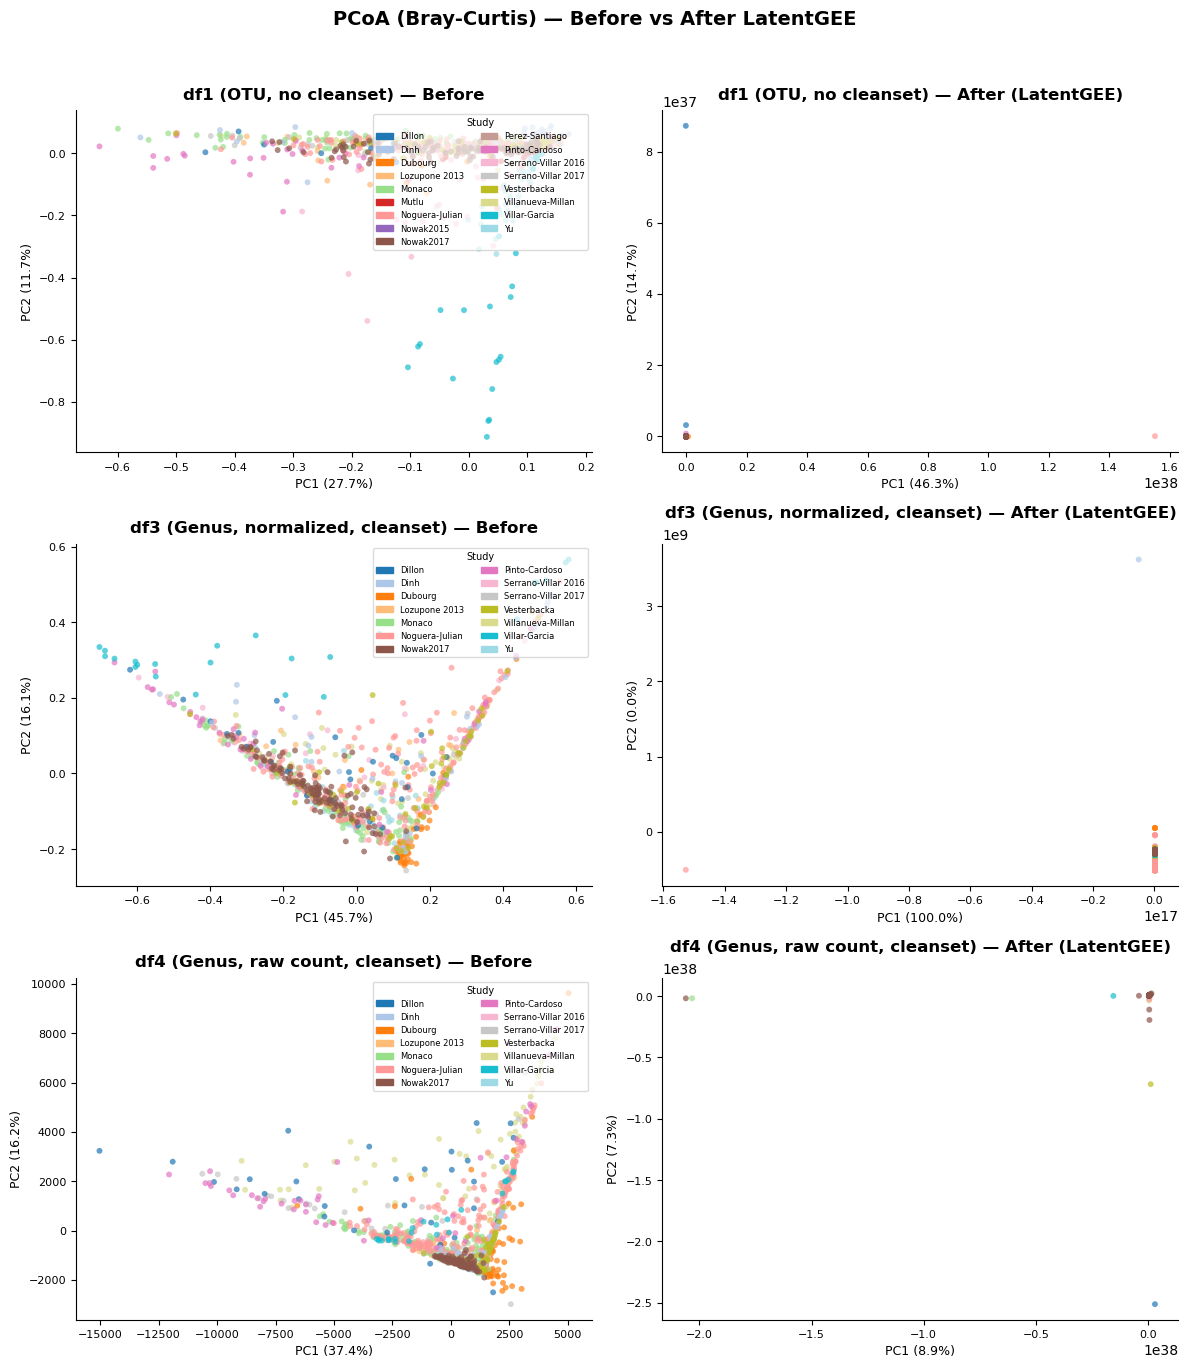

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from scipy.spatial.distance import braycurtis
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import LabelEncoder

def pcoa(X, metric='braycurtis'):
    """Bray-Curtis distance 기반 PCoA (classical MDS)"""
    dist_mat = squareform(pdist(X, metric=metric))
    n = dist_mat.shape[0]
    # Double centering
    H = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * H @ (dist_mat ** 2) @ H
    eigvals, eigvecs = np.linalg.eigh(B)
    # 내림차순 정렬
    idx = np.argsort(eigvals)[::-1]
    eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]
    # 양수 eigenvalue만 사용
    pos = eigvals > 0
    coords = eigvecs[:, pos] * np.sqrt(eigvals[pos])
    var_explained = eigvals[pos] / eigvals[pos].sum() * 100
    return coords[:, :2], var_explained[:2]

def plot_pcoa_grid(datasets, metric='braycurtis', save_path=None, dpi=150):
    """
    datasets: list of dict
        {
            'label': str,          # e.g. 'df1'
            'X_before': array,
            'X_after': array,
            'batch': array,
        }
    """
    n_datasets = len(datasets)
    fig, axes = plt.subplots(n_datasets, 2,
                             figsize=(12, 4.5 * n_datasets),
                             facecolor='white')

    # 전체 study 색상 팔레트 통일
    all_studies = np.unique(np.concatenate([d['batch'] for d in datasets]))
    cmap = plt.cm.get_cmap('tab20', len(all_studies))
    color_map = {s: cmap(i) for i, s in enumerate(all_studies)}

    for row, data in enumerate(datasets):
        label     = data['label']
        X_before  = np.array(data['X_before'])
        X_after   = np.array(data['X_after'])
        batch     = np.array(data['batch'])

        for col, (X, title) in enumerate([
            (X_before, f"{label} — Before"),
            (X_after,  f"{label} — After (LatentGEE)")
        ]):
            ax = axes[row, col] if n_datasets > 1 else axes[col]

            coords, var_exp = pcoa(X, metric=metric)
            colors = [color_map[s] for s in batch]

            ax.scatter(coords[:, 0], coords[:, 1],
                       c=colors, s=18, alpha=0.7, linewidths=0)

            ax.set_title(title, fontsize=12, fontweight='bold', pad=8)
            ax.set_xlabel(f"PC1 ({var_exp[0]:.1f}%)", fontsize=9)
            ax.set_ylabel(f"PC2 ({var_exp[1]:.1f}%)", fontsize=9)
            ax.tick_params(labelsize=8)
            ax.spines[['top', 'right']].set_visible(False)

            # Before 패널에만 legend 표시
            if col == 0:
                studies = np.unique(batch)
                handles = [mpatches.Patch(color=color_map[s], label=s) for s in studies]
                ax.legend(handles=handles, fontsize=6, loc='upper right',
                          ncol=2, framealpha=0.7,
                          title='Study', title_fontsize=7)

    plt.suptitle("PCoA (Bray-Curtis) — Before vs After LatentGEE",
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        print(f"저장됨: {save_path}")
    plt.show()


# ── 실행 ──────────────────────────────────────────────
datasets = [
    {
        'label':    'df1 (OTU, no cleanset)',
        'X_before': X_filtered_df1.values,
        'X_after':  X_corrected_df1_clean.values,
        'batch':    batch_df1,
    },
    {
        'label':    'df3 (Genus, normalized, cleanset)',
        'X_before': X_filtered_df3.values,
        'X_after':  X_corrected_df3_clean.values,
        'batch':    batch_df3,
    },
    {
        'label':    'df4 (Genus, raw count, cleanset)',
        'X_before': X_filtered_df4.values,
        'X_after':  X_corrected_df4_clean.values,
        'batch':    batch_df4,
    },
]

plot_pcoa_grid(
    datasets,
    metric='braycurtis',
    save_path="/DATA/WGS_study/YSL/projects/latentgee/examples/results/figures/pcoa_braycurtis.png"
)


plot_pcoa_grid(
    datasets,
    metric='euclidean',
    save_path="/DATA/WGS_study/YSL/projects/latentgee/examples/results/figures/pcoa_euclidean.png"
)

In [21]:
print(X_corrected_df1_clean.sum(axis=1).describe())
print(X_corrected_df4_clean.sum(axis=1).describe())

count    1.032000e+03
mean     1.009428e+36
std      7.390406e+36
min      1.236943e+07
25%      9.292107e+28
50%      1.249391e+32
75%      1.324397e+34
max      1.553291e+38
dtype: float64
count    9.360000e+02
mean     9.173189e+36
std      3.160652e+37
min      1.456657e+15
25%      6.451049e+28
50%      1.107678e+33
75%      1.058382e+36
max      2.877048e+38
dtype: float64


In [20]:
for name, X in [("df1", X_corrected_df1_clean), 
                ("df3", X_corrected_df3_clean), 
                ("df4", X_corrected_df4_clean)]:
    print(f"{name} — max: {X.values.max():.4f}, "
          f"99th percentile: {np.percentile(X.values, 99):.4f}, "
          f"values > 1 인 셀 수: {(X.values > 1).sum()}")

df1 — max: 155328330000000003558401972247136829440.0000, 99th percentile: 528453897.1000, values > 1 인 셀 수: 87168
df3 — max: 152879670000000000.0000, 99th percentile: 0.0775, values > 1 인 셀 수: 92
df4 — max: 251691279999999988377618450899189891072.0000, 99th percentile: 93953317300006949697481605120.0000, values > 1 인 셀 수: 75514
